# 24-Hour Session Liquidity & Volatility Heatmap
*(Per-Symbol Normalized — each row reflects that symbol's own distribution)*

Fetches 24-hour tick + bar data from MetaTrader 5 and produces:
1. **Spread Heatmap** – hourly avg spread, colored relative to each symbol's own 24h range.
2. **Volatility Heatmap** – hourly High-Low range, same per-symbol normalization.
3. **Efficiency Heatmap** – `Volatility / Spread`, also per-symbol normalized.

### Why per-symbol normalization?
A 10-pip spread may be abnormally wide for EURUSD but default for NZDUSD. 
50 pips of range may be strong for EURUSD but very weak for XAUUSD.
Each row is scaled independently: **0 = calmest/tightest hour, 1 = busiest/widest**.

### Trading Sessions (UTC)
| Session | Hours |
|---|---|
| Asian | 00:00 – 08:00 |
| London | 08:00 – 16:00 |
| New York | 13:00 – 21:00 |
| London/NY Overlap | 13:00 – 16:00 |
| Interbank Rollover | 23:00 – 01:00 |


In [2]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch, Rectangle
from datetime import datetime, timedelta, UTC

plt.style.use('dark_background')
print("✓ Analytics environment initialized.")


✓ Analytics environment initialized.


In [3]:
if not mt5.initialize():
    raise RuntimeError(f"MT5 initialization failed: {mt5.last_error()}")

info = mt5.terminal_info()
print(f"Connected: {info.name} ({info.company}) | Build {mt5.version()}")


Connected: RoboForex MT5 Terminal (RoboForex Ltd) | Build (500, 6061, '24 Jul 2026')


In [12]:
def get_last_valid_trading_day() -> tuple[datetime, datetime]:
    '''Finds the most recent full weekday trading day (skipping weekends).'''
    now = datetime.now()
    day = now.date()
    for _ in range(7):
        if day.weekday() < 5:
            break
        day -= timedelta(days=1)

    if day == now.date() and now.hour < 3:
        day -= timedelta(days=1)
        while day.weekday() >= 5:
            day -= timedelta(days=1)

    return (
        datetime.combine(day, datetime.min.time(), tzinfo=UTC),
        datetime.combine(day, datetime.max.time().replace(microsecond=0),tzinfo=UTC),
    )

def build_24h_matrices(symbols):
    '''Fetches tick and rate history across 24 hours for all symbols.'''
    date_from, date_to = get_last_valid_trading_day()
    print(f"Fetching 24-Hour Session Data for target day: {date_from.strftime('%Y-%m-%d')}...")

    sp, vol, vm = {}, {}, {}
    unit_map = {}

    for sym in symbols:
        info = mt5.symbol_info(sym)
        if info is None:
            print(f"⚠️ Symbol '{sym}' not found in Market Watch. Skipping.")
            continue

        point = info.point if info.point > 0 else 0.00001
        digits = info.digits
        print(sym,point,digits)
        if digits in [3, 5]:
            unit, scale = "pips", 10.0 * point
        elif digits == 2 and any(k in sym for k in ("USD", "WTI", "BRENT")):
            unit, scale = "cents", point
        else:
            unit, scale = "pts", point

        label = f"{sym} ({unit})"
        unit_map[sym] = (unit, scale)

        # Spread Data (Ticks)
        ticks = mt5.copy_ticks_range(sym, date_from, date_to, mt5.COPY_TICKS_ALL)
        if ticks is not None and len(ticks) > 0:
            dt = pd.DataFrame(ticks)
            dt["datetime"] = pd.to_datetime(dt["time_msc"], unit="ms")
            dt["hour"] = dt["datetime"].dt.hour
            dt["sp"] = (dt["ask"] - dt["bid"]) / scale
            sp[label] = dt.groupby("hour")["sp"].mean().reindex(range(24)).fillna(0)

        # Volatility Data (H1 Rates)
        rates = mt5.copy_rates_range(sym, mt5.TIMEFRAME_H1, date_from, date_to)
        if rates is not None and len(rates) > 0:
            dr = pd.DataFrame(rates)
            dr["hour"] = pd.to_datetime(dr["time"], unit="s").dt.hour
            dr["rng"] = (dr["high"] - dr["low"]) / scale
            vol[label] = dr.groupby("hour")["rng"].mean().reindex(range(24)).fillna(0)
            vm[label] = dr.groupby("hour")["tick_volume"].sum().reindex(range(24)).fillna(0)

    df_spread = pd.DataFrame(sp)
    df_vol = pd.DataFrame(vol)
    df_volm = pd.DataFrame(vm)

    print(f"✓ Built matrices for {len(df_spread.columns)} instruments across 24 hours.")
    return df_spread, df_vol, df_volm, unit_map

symbols_to_analyze = ['EURUSD', 'GBPUSD','AUDUSD', 'WTI', 'XAUUSD', '.US500Cash']
df_spread, df_vol, df_volm, unit_map = build_24h_matrices(symbols_to_analyze)


Fetching 24-Hour Session Data for target day: 2026-07-27...
EURUSD 1e-05 5
GBPUSD 1e-05 5
AUDUSD 1e-05 5
WTI 0.01 2
XAUUSD 0.01 2
.US500Cash 0.1 1
✓ Built matrices for 6 instruments across 24 hours.


In [14]:
def row_normalize(data):
    '''Scale each row (symbol) independently: min=0, max=1.'''
    normed = np.zeros_like(data, dtype=float)
    for i in range(data.shape[0]):
        lo, hi = data[i].min(), data[i].max()
        if hi > lo:
            normed[i] = (data[i] - lo) / (hi - lo)
        else:
            normed[i] = 0.5
    return normed

SESSION_BANDS = [
    (0, 1, "Rollover", "#FF1744"),
    (1,  12,  "Asian",    "#00E676"),
    (10,  19, "London",   "#00B0FF"),
    (15, 24, "New York", "#FF9100"),
]

def add_session_bands(ax):
    for start, end, label, color in SESSION_BANDS:
        rect = Rectangle((start-0.5, -0.75), end-start, 0.22,
                          facecolor=color, alpha=0.85, clip_on=False)
        ax.add_patch(rect)
        ax.text((start+end)/2-0.5, -0.64, label, ha="center", va="center",
                color="black", fontsize=7.5, fontweight="bold", clip_on=False)

HOUR_LABELS = [f"{h:02d}:00" for h in range(24)]


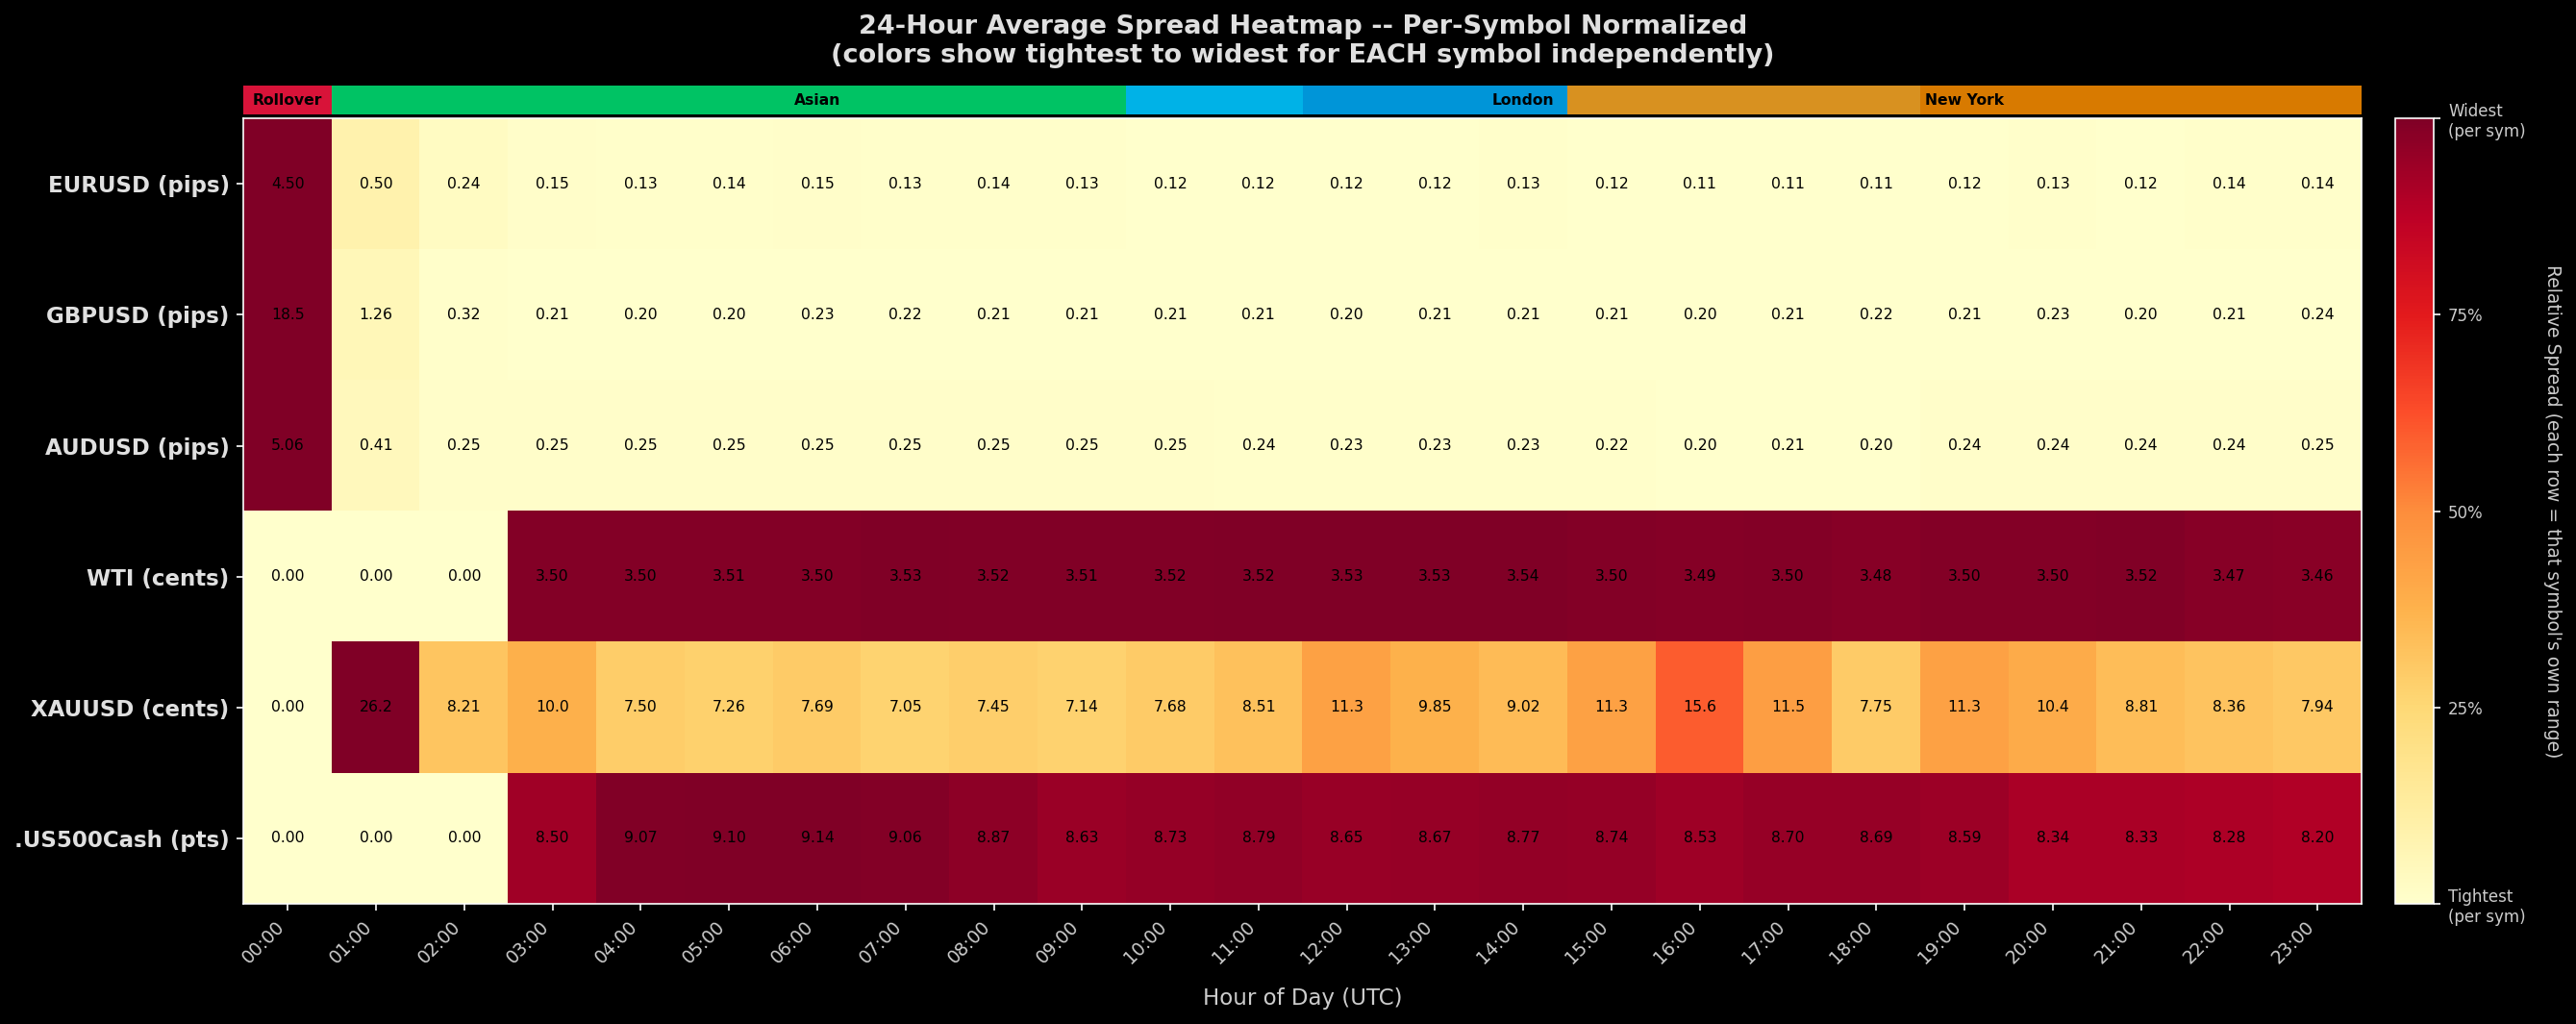

In [16]:
def plot_spread_heatmap(df):
    raw  = df.T.values
    norm = row_normalize(raw)
    syms = list(df.columns)
    n    = len(syms)

    fig, ax = plt.subplots(figsize=(18, max(5, n * 1.2)), dpi=150)
    im = ax.imshow(norm, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

    cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.025)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(["Tightest\n(per sym)", "25%", "50%", "75%", "Widest\n(per sym)"],
                        color="#CCCCCC", fontsize=8)
    cbar.set_label("Relative Spread (each row = that symbol's own range)",
                   rotation=270, labelpad=18, color="#CCCCCC", fontsize=9)

    ax.set_xticks(range(24))
    ax.set_xticklabels(HOUR_LABELS, rotation=45, ha="right", fontsize=9, color="#CCCCCC")
    ax.set_yticks(range(n))
    ax.set_yticklabels(syms, fontsize=11, fontweight="bold", color="#E0E0E0")

    for i in range(n):
        for j in range(24):
            val = raw[i, j]
            txt = f"{val:.2f}" if val < 10 else f"{val:.1f}"
            tc  = "black"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=7.5)

    ax.set_title(
        "24-Hour Average Spread Heatmap -- Per-Symbol Normalized\n"
        "(colors show tightest to widest for EACH symbol independently)",
        fontsize=13, pad=28, fontweight="bold", color="#E0E0E0")
    ax.set_xlabel("Hour of Day (UTC)", fontsize=11, labelpad=10, color="#CCCCCC")

    add_session_bands(ax)
    plt.tight_layout()
    plt.show()

plot_spread_heatmap(df_spread)


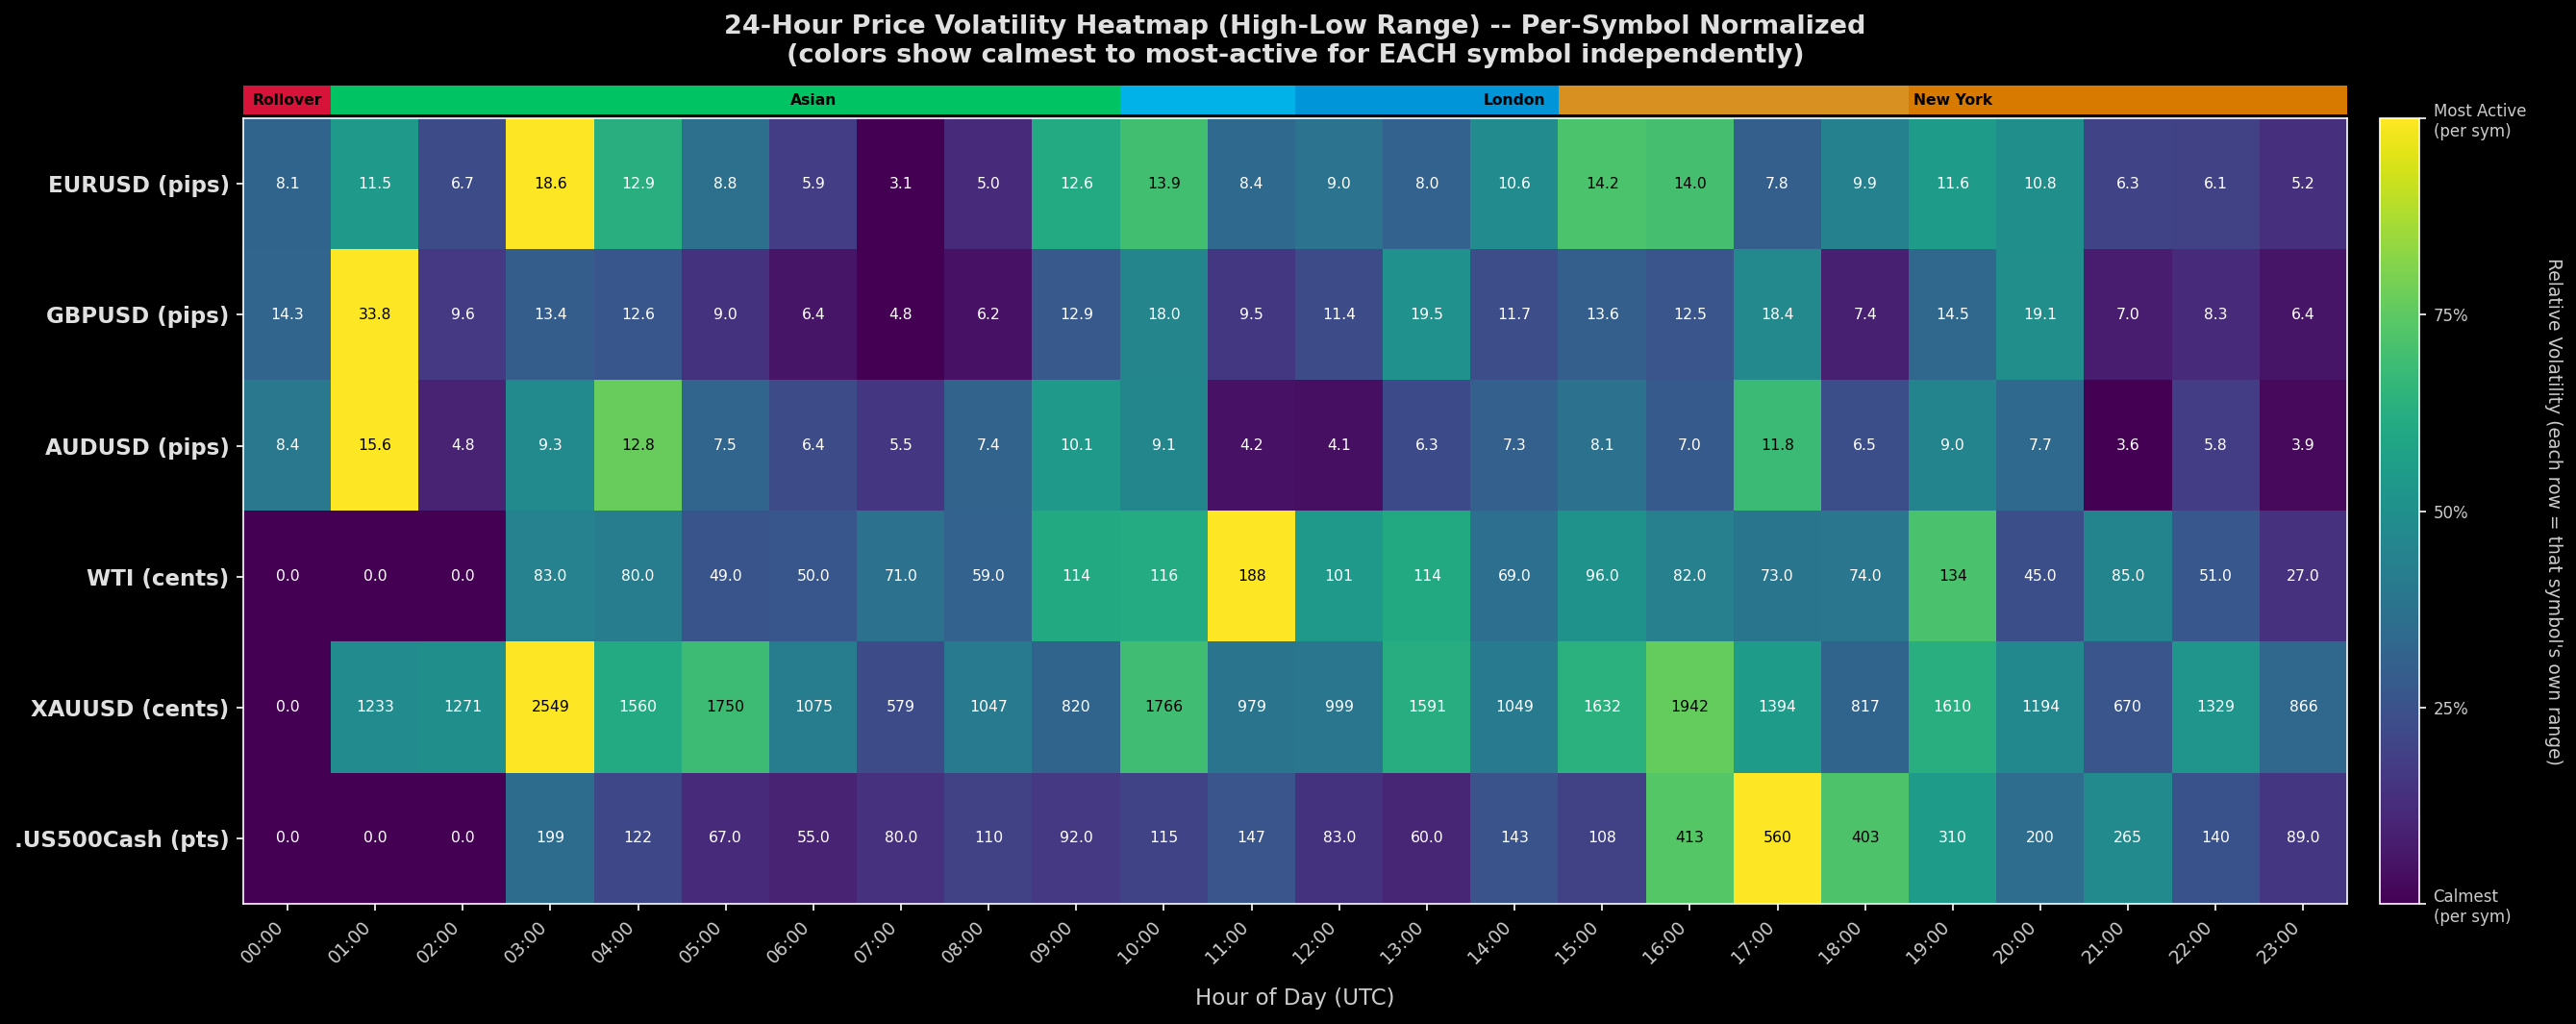

In [7]:
def plot_volatility_heatmap(df):
    raw  = df.T.values
    norm = row_normalize(raw)
    syms = list(df.columns)
    n    = len(syms)

    fig, ax = plt.subplots(figsize=(18, max(5, n * 1.2)), dpi=150)
    im = ax.imshow(norm, cmap="viridis", aspect="auto", vmin=0, vmax=1)

    cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.025)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(["Calmest\n(per sym)", "25%", "50%", "75%", "Most Active\n(per sym)"],
                        color="#CCCCCC", fontsize=8)
    cbar.set_label("Relative Volatility (each row = that symbol's own range)",
                   rotation=270, labelpad=18, color="#CCCCCC", fontsize=9)

    ax.set_xticks(range(24))
    ax.set_xticklabels(HOUR_LABELS, rotation=45, ha="right", fontsize=9, color="#CCCCCC")
    ax.set_yticks(range(n))
    ax.set_yticklabels(syms, fontsize=11, fontweight="bold", color="#E0E0E0")

    for i in range(n):
        for j in range(24):
            val = raw[i, j]
            txt = f"{val:.1f}" if val < 100 else f"{val:.0f}"
            tc  = "black" if norm[i, j] > 0.65 else "white"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=7.5)

    ax.set_title(
        "24-Hour Price Volatility Heatmap (High-Low Range) -- Per-Symbol Normalized\n"
        "(colors show calmest to most-active for EACH symbol independently)",
        fontsize=13, pad=28, fontweight="bold", color="#E0E0E0")
    ax.set_xlabel("Hour of Day (UTC)", fontsize=11, labelpad=10, color="#CCCCCC")

    add_session_bands(ax)
    plt.tight_layout()
    plt.show()

plot_volatility_heatmap(df_vol)


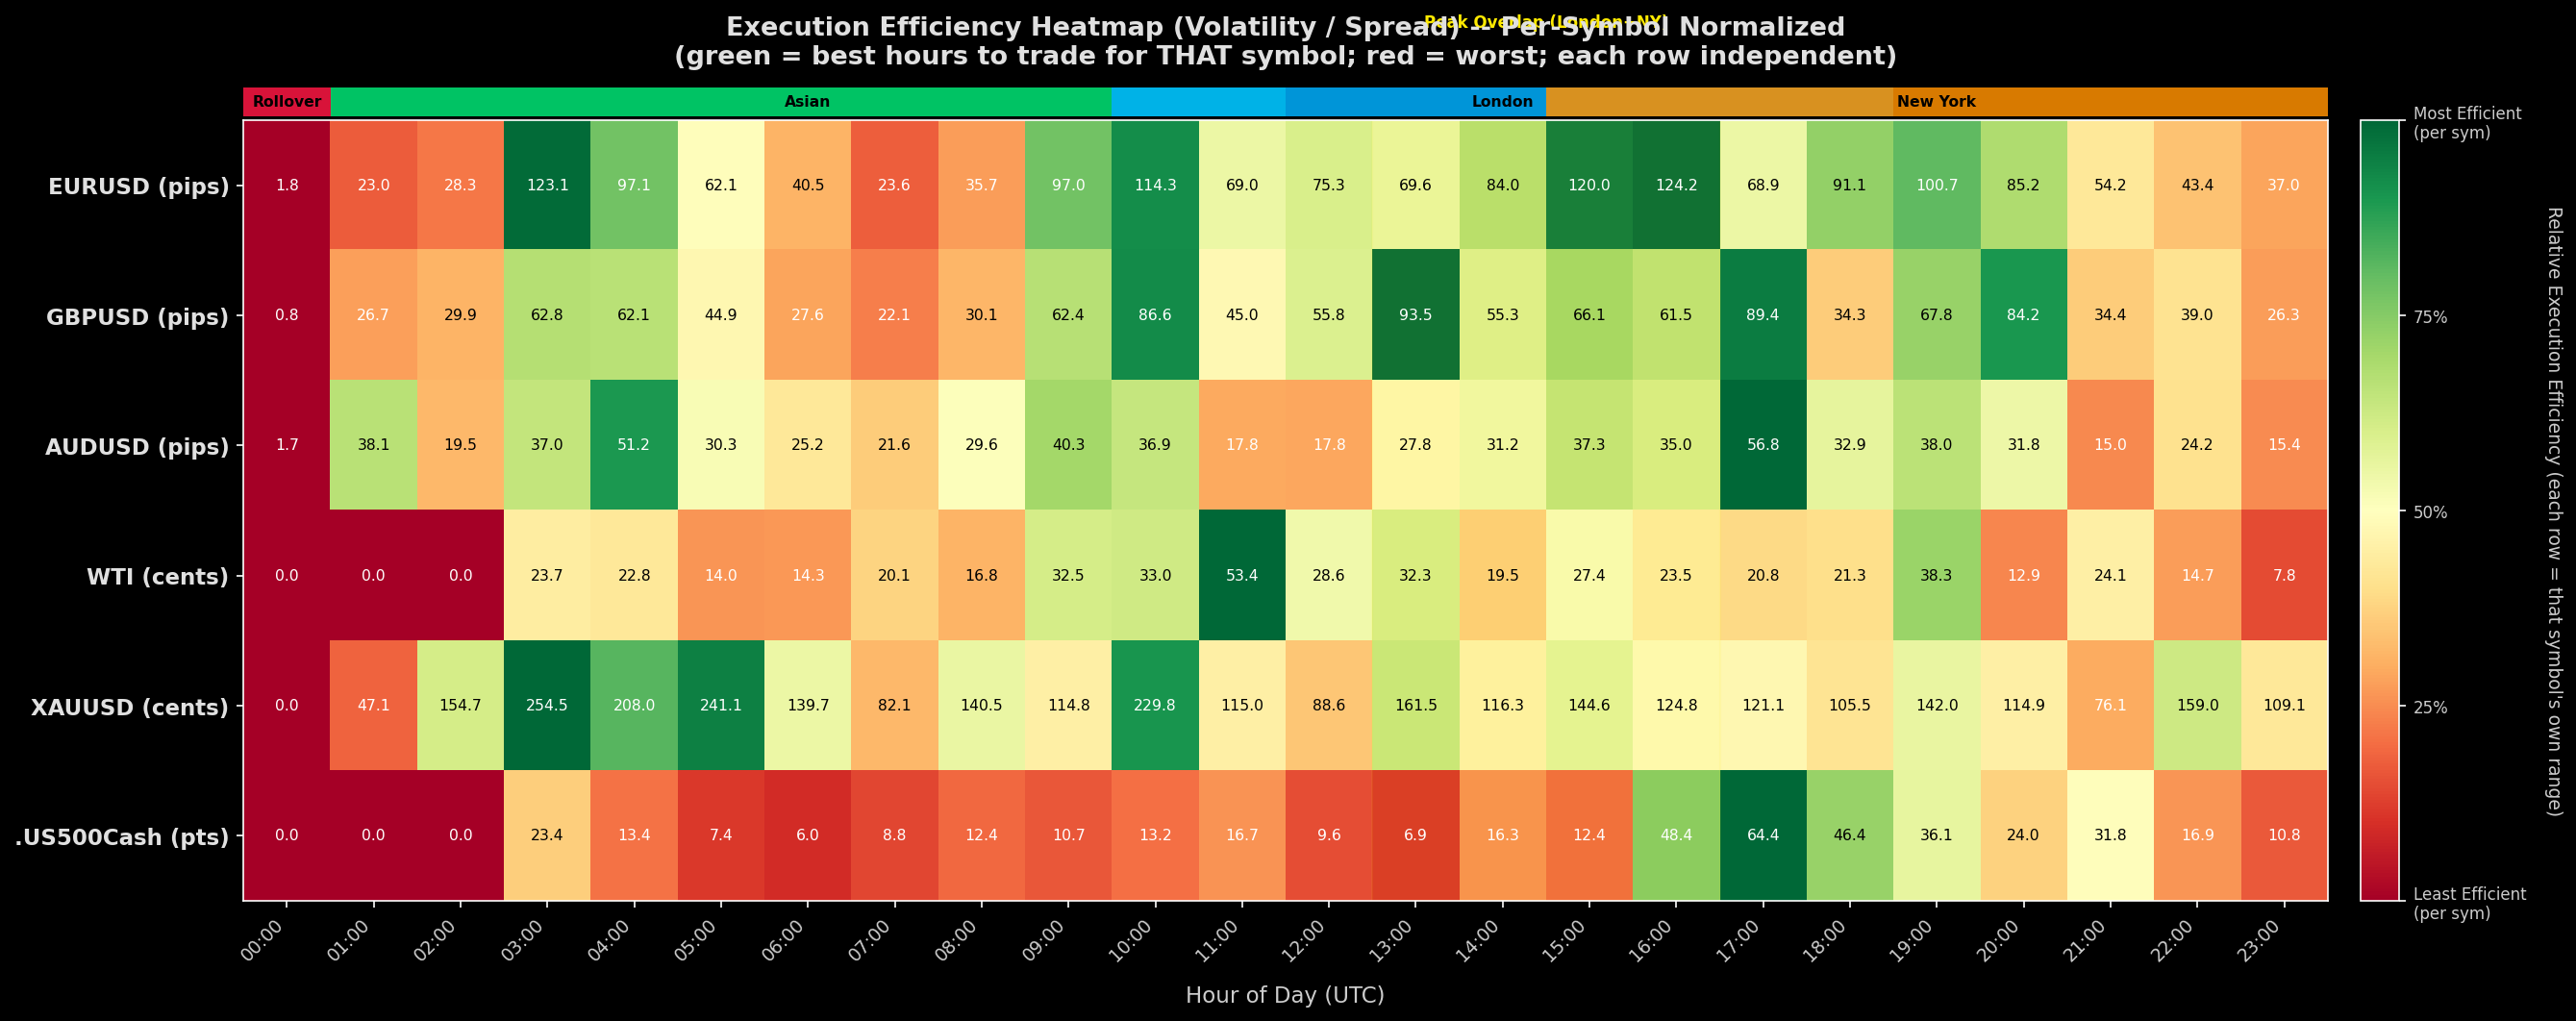

In [8]:
def plot_efficiency_heatmap(df_sp, df_v):
    sp_safe = df_sp.replace(0, np.nan)
    eff_raw = (df_v / sp_safe).fillna(0)

    raw  = eff_raw.T.values
    norm = row_normalize(raw)
    syms = list(eff_raw.columns)
    n    = len(syms)

    fig, ax = plt.subplots(figsize=(18, max(5, n * 1.2)), dpi=150)
    im = ax.imshow(norm, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

    cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.025)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(["Least Efficient\n(per sym)", "25%", "50%", "75%", "Most Efficient\n(per sym)"],
                        color="#CCCCCC", fontsize=8)
    cbar.set_label("Relative Execution Efficiency (each row = that symbol's own range)",
                   rotation=270, labelpad=18, color="#CCCCCC", fontsize=9)

    ax.set_xticks(range(24))
    ax.set_xticklabels(HOUR_LABELS, rotation=45, ha="right", fontsize=9, color="#CCCCCC")
    ax.set_yticks(range(n))
    ax.set_yticklabels(syms, fontsize=11, fontweight="bold", color="#E0E0E0")

    for i in range(n):
        for j in range(24):
            val = raw[i, j]
            txt = f"{val:.1f}" if val < 1000 else f"{val/1000:.1f}k"
            tc  = "black" if 0.3 < norm[i, j] < 0.75 else "white"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=7.5)

    ax.set_title(
        "Execution Efficiency Heatmap (Volatility / Spread) -- Per-Symbol Normalized\n"
        "(green = best hours to trade for THAT symbol; red = worst; each row independent)",
        fontsize=13, pad=28, fontweight="bold", color="#E0E0E0")
    ax.set_xlabel("Hour of Day (UTC)", fontsize=11, labelpad=10, color="#CCCCCC")

    add_session_bands(ax)

    # Highlight London/NY overlap zone
    ax.axvspan(12.5, 16.5, color="#FFEA00", alpha=0.07, zorder=0)
    ax.text(14.5, -1.25, "Peak Overlap (London+NY)",
            ha="center", va="center", color="#FFEA00",
            fontsize=8, fontweight="bold", clip_on=False)

    plt.tight_layout()
    plt.show()
    return eff_raw

df_eff = plot_efficiency_heatmap(df_spread, df_vol)


In [9]:
def summary_table():
    rows = []
    for col in df_spread.columns:
        sym = col.split(" ")[0]
        unit, _ = unit_map.get(sym, ("?", 1))

        sp  = df_spread[col]
        vol = df_vol[col] if col in df_vol.columns else pd.Series([0]*24)
        eff = df_eff[col] if (df_eff is not None and col in df_eff.columns) else pd.Series([0]*24)

        rows.append({
            "Symbol":         sym,
            "Unit":           unit,
            "Avg 24h Spread": f"{sp.mean():.3f}",
            "Tightest Hr":    f"{int(sp.idxmin()):02d}:00 UTC",
            "Widest Hr":      f"{int(sp.idxmax()):02d}:00 UTC",
            "Peak Vol Hr":    f"{int(vol.idxmax()):02d}:00 UTC",
            "Best Trade Hr":  f"{int(eff.idxmax()):02d}:00 UTC",
        })

    df_s = pd.DataFrame(rows)
    print("=== 24-Hour Session Liquidity Summary ===")
    print(df_s.to_string(index=False))

summary_table()


=== 24-Hour Session Liquidity Summary ===
    Symbol  Unit Avg 24h Spread Tightest Hr Widest Hr Peak Vol Hr Best Trade Hr
    EURUSD  pips          0.329   18:00 UTC 00:00 UTC   03:00 UTC     16:00 UTC
    GBPUSD  pips          1.024   05:00 UTC 00:00 UTC   01:00 UTC     13:00 UTC
    AUDUSD  pips          0.445   18:00 UTC 00:00 UTC   01:00 UTC     17:00 UTC
       WTI cents          3.068   00:00 UTC 14:00 UTC   11:00 UTC     11:00 UTC
    XAUUSD cents          9.492   00:00 UTC 01:00 UTC   03:00 UTC     03:00 UTC
.US500Cash   pts          7.599   00:00 UTC 06:00 UTC   17:00 UTC     17:00 UTC


## How to Read These Heatmaps

### Per-Symbol Normalization
Each **row** is independently scaled 0.0 to 1.0. 
| Color | Spread heatmap | Volatility heatmap | Efficiency heatmap |
|---|---|---|---|
| **Dark / Cool** | Tightest spread | Calmest movement | Worst reward/cost |
| **Bright / Hot** | Widest spread | Most active | Best reward/cost |

### Execution Efficiency = Volatility / Spread
How much price movement you get per unit of spread you pay.
- Best hours: tight spread AND high volatility (upper-right of efficiency score).
- Worst hours: wide spread AND low volatility (rollover window, 23:00-01:00 UTC).
